In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv('../data/raw/ec2_cpu_utilization_24ae8d.csv', parse_dates=['timestamp'])
df = df.set_index('timestamp')

m = 288

In [3]:
tamanho_treino = int(len(df) * 0.8)
treino = df.iloc[:tamanho_treino].copy()
teste = df.iloc[tamanho_treino:].copy()

In [4]:
posicao_treino = np.arange(len(treino)) % m
perfil_sazonal = pd.Series(treino['value'].values, index=posicao_treino).groupby(level=0).mean()

In [5]:
posicao_global_teste = np.arange(tamanho_treino, tamanho_treino + len(teste)) % m
esperado_teste = perfil_sazonal.reindex(posicao_global_teste).values

residuo_teste = pd.Series(teste['value'].values - esperado_teste, index=teste.index)

In [6]:
with open('../data/labels/combined_windows.json') as f:
    labels = json.load(f)

windows = labels['realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv']
windows = [(pd.Timestamp(w[0]), pd.Timestamp(w[1])) for w in windows]

dentro_anomalia = pd.Series(False, index=teste.index)
for start, end in windows:
    dentro_anomalia |= (teste.index >= start) & (teste.index <= end)

In [7]:
janela = 12  # 12 pontos de 5min = 1 hora

std_movel = residuo_teste.abs().rolling(window=janela, min_periods=janela).std()

In [8]:
std_normal = std_movel[~dentro_anomalia].dropna()
std_anomalo = std_movel[dentro_anomalia].dropna()

comparacao_std = pd.DataFrame({
    'normal (fora da janela)': std_normal.describe(),
    'anômalo (dentro da janela)': std_anomalo.describe(),
})
comparacao_std

,normal (fora da janela),anômalo (dentro da janela)
count,394.000000,402.000000
mean,0.043620,0.056028
std,0.084157,0.121668
min,0.007444,0.008032
25%,0.016868,0.017767
50%,0.021363,0.020548
75%,0.025387,0.024325
max,0.388778,0.634083


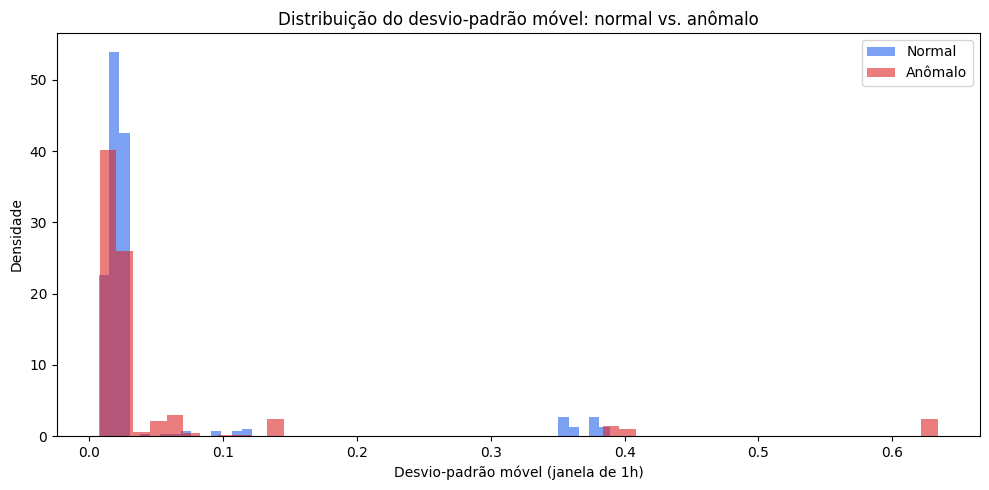

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(std_normal, bins=50, alpha=0.6, label='Normal', color='#2563eb', density=True)
ax.hist(std_anomalo, bins=50, alpha=0.6, label='Anômalo', color='#dc2626', density=True)
ax.set_xlabel('Desvio-padrão móvel (janela de 1h)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição do desvio-padrão móvel: normal vs. anômalo')
ax.legend()
plt.tight_layout()
plt.show()

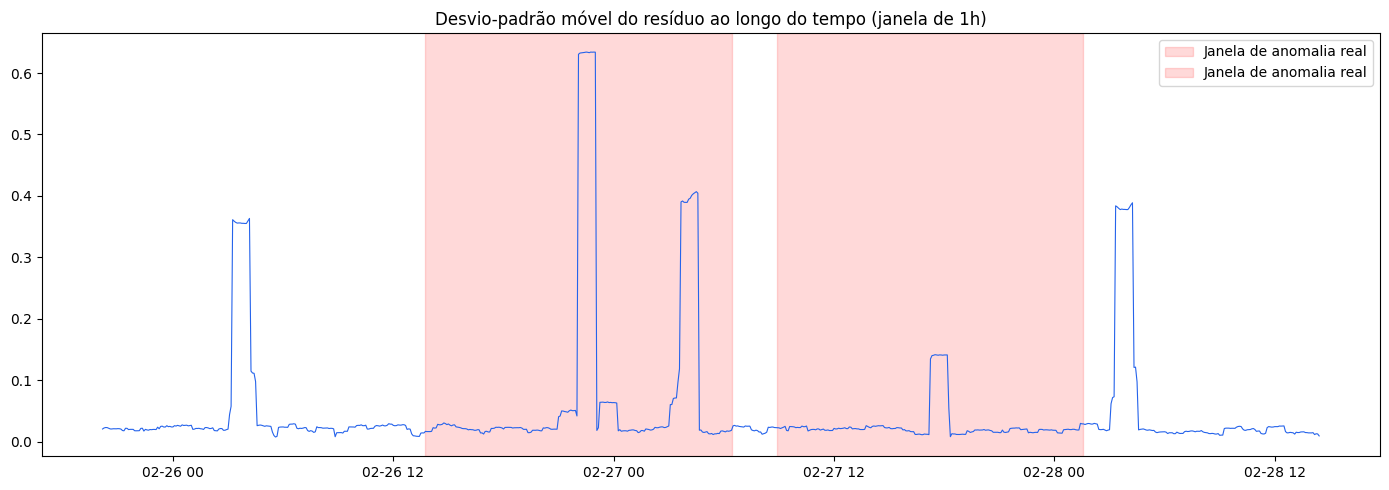

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(std_movel.index, std_movel, linewidth=0.8, color='#2563eb')
for start, end in windows:
    ax.axvspan(start, end, color='red', alpha=0.15, label='Janela de anomalia real')
ax.set_title('Desvio-padrão móvel do resíduo ao longo do tempo (janela de 1h)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
for janela_teste in [6, 12, 24, 36]:  # 30min, 1h, 2h, 3h
    std_teste = residuo_teste.abs().rolling(window=janela_teste, min_periods=janela_teste).std()
    std_n = std_teste[~dentro_anomalia].dropna()
    std_a = std_teste[dentro_anomalia].dropna()
    print(f'Janela = {janela_teste} pontos ({janela_teste*5} min):')
    print(f'  Normal  -> mediana: {std_n.median():.4f} | p95: {std_n.quantile(0.95):.4f} | max: {std_n.max():.4f}')
    print(f'  Anômalo -> mediana: {std_a.median():.4f} | p95: {std_a.quantile(0.95):.4f} | max: {std_a.max():.4f}')
    print()

Janela = 6 pontos (30 min):
  Normal  -> mediana: 0.0196 | p95: 0.0958 | max: 0.5221
  Anômalo -> mediana: 0.0204 | p95: 0.0892 | max: 0.8989

Janela = 12 pontos (60 min):
  Normal  -> mediana: 0.0214 | p95: 0.3555 | max: 0.3888
  Anômalo -> mediana: 0.0205 | p95: 0.3902 | max: 0.6341

Janela = 24 pontos (120 min):
  Normal  -> mediana: 0.0216 | p95: 0.2804 | max: 0.2820
  Anômalo -> mediana: 0.0211 | p95: 0.4463 | max: 0.4486

Janela = 36 pontos (180 min):
  Normal  -> mediana: 0.0223 | p95: 0.2329 | max: 0.2384
  Anômalo -> mediana: 0.0220 | p95: 0.3661 | max: 0.3671



: 